In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

Reading the data

In [2]:
california_houses = pd.read_csv('California_Houses.csv')

california_houses.describe()


,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928682,117395.477505
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019101,1.736675e+05,2.147398e+05,459758.877000,526546.661701
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414479,5.271562e+05,7.057954e+05,516946.490963,584552.007907
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298


splitting the data

In [3]:
#separate the prices (output we want to predict) from the features (x)
#drop the column (axis=1) from features X
x=california_houses.drop('Median_House_Value', axis=1)
#store them in y (output)
y=california_houses['Median_House_Value']

#split the data to 70% training, 30%
X_train, X_t, y_train, y_t = train_test_split(x, y, test_size=0.3, random_state=42)
#then to 15% val, 15% testing,random_state= any number, to use the same random testing every time
X_val, X_test, y_val, y_test = train_test_split(X_t, y_t, test_size=0.5, random_state=42)

#checking the split ratios
total_len = len(california_houses)
train_ratio = len(X_train) / total_len
val_ratio = len(X_val) / total_len
test_ratio = len(X_test) / total_len

print(f"Train: {train_ratio:.2%}, Val: {val_ratio:.2%}, Test: {test_ratio:.2%}")


Train: 70.00%, Val: 15.00%, Test: 15.00%


Linear Regression Manually

In [4]:
# Add polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

#feature scaling (standardization) to have mean=0 and std=1 for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)
X_test_scaled = scaler.transform(X_test_poly)

#adding a ones column to the features for the bias (intercept)
#creates an array of ones with the same number of rows as X_train
#.c_ concatenates the ones column to X_train to the left side
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

#normal equation method
#theta_best = (X^T * X)^-1 * X^T * y
#linalg-> linear algebra
theta_best = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)

#predictions
# @ is matrix multiplication(dot product)
y_train_pred_linear_normal = X_train_b @ theta_best
y_val_pred_linear_normal = X_val_b @ theta_best
y_test_pred_linear_normal = X_test_b @ theta_best

#mean squared error
mse_train_linear = mean_squared_error(y_train, y_train_pred_linear_normal)
mse_val_linear = mean_squared_error(y_val, y_val_pred_linear_normal)
mse_test_linear = mean_squared_error(y_test, y_test_pred_linear_normal)
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear_normal)
mae_val_linear = mean_absolute_error(y_val, y_val_pred_linear_normal)
mae_test_linear = mean_absolute_error(y_test, y_test_pred_linear_normal)

print(f"Linear Regression normal MSE: Train: {mse_train_linear:.2f}, Val: {mse_val_linear:.2f}, Test: {mse_test_linear:.2f}")
print(f"Linear Regression normal MAE: Train: {mae_train_linear:.2f}, Val: {mae_val_linear:.2f}, Test: {mae_test_linear:.2f}")


Linear Regression normal MSE: Train: 3493387488.32, Val: 3770950734.86, Test: 3285669880.92
Linear Regression normal MAE: Train: 41543.10, Val: 42270.92, Test: 40821.75


linear regression using gradient descent 

Linear Regression GD MSE: Train: 4386312935.16, Val: 4563941249.55, Test: 4123560803.82
Linear Regression GD MAE: Train: 46970.60, Val: 47662.79, Test: 46246.77


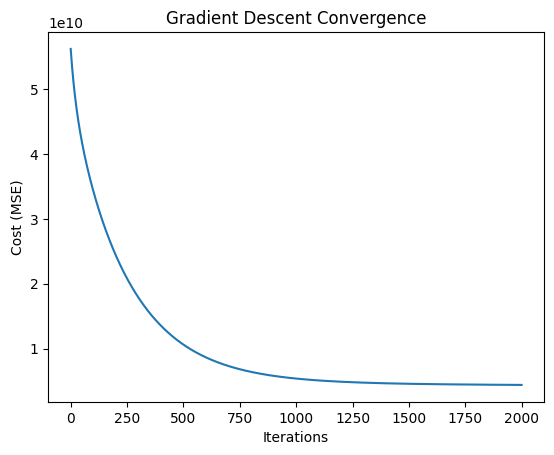

In [5]:
#n_iteration = number of steps that the gradient descent will take to reach the minimum
#learning_rate controls the step size
#y=wx+b
#X-> (n_samples, n_features)
def gradient_descent(X, y, learning_rate=0.01, n_iterations=10000):
    #initialize theta (weights) to zeros (the slopes of the features)
    #weight vector of size equal to number of features
    w=np.zeros(X.shape[1])
    #n= n_samples (number of rows in X)
    n=len(X)

    costs=[]

    for iteration in range(n_iterations):
        #predictions, y=wx
        y_pred = X @ w
        #gradient of the loss function (MSE) wrt weights
        #MSE = (1/n) * sum((y - y_pred)^2)
        #derivative of MSE wrt w = (-2/n) * X^T * (y - y_pred)
        #gradient is the slope of the loss function
        gradients = (-2/n) * X.T @ (y - y_pred)
        #update the weights
        #w=slope 
        #step_size= learning_rate*slope(gradient)
        #w= old_w - step_size
        w = w - learning_rate * gradients

        cost= mean_squared_error(y, y_pred)
        costs.append(cost)

        if np.isnan(cost) or np.isinf(cost):
            print(f"Cost exploded at iteration {iteration}")
            break
        
    return w, costs

#predictions
# Increase iterations and adjust learning rate
theta_gd, costs = gradient_descent(X_train_b, y_train, learning_rate=0.001, n_iterations=2000)
y_train_pred_linear_gd = X_train_b @ theta_gd
y_val_pred_linear_gd = X_val_b @ theta_gd
y_test_pred_linear_gd = X_test_b @ theta_gd

#mean squared error penalized for large errors more
linear_gd_mse_train = mean_squared_error(y_train, y_train_pred_linear_gd)
linear_gd_mse_val = mean_squared_error(y_val, y_val_pred_linear_gd)
linear_gd_mse_test = mean_squared_error(y_test, y_test_pred_linear_gd)
print(f"Linear Regression GD MSE: Train: {linear_gd_mse_train:.2f}, Val: {linear_gd_mse_val:.2f}, Test: {linear_gd_mse_test:.2f}")
#mean absolute error penalized for all errors equally
linear_gd_mae_train = mean_absolute_error(y_train, y_train_pred_linear_gd)
linear_gd_mae_val = mean_absolute_error(y_val, y_val_pred_linear_gd)
linear_gd_mae_test = mean_absolute_error(y_test, y_test_pred_linear_gd)
print(f"Linear Regression GD MAE: Train: {linear_gd_mae_train:.2f}, Val: {linear_gd_mae_val:.2f}, Test: {linear_gd_mae_test:.2f}")

# Plotting the cost over iterations to visualize convergence
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

linear regression using sicklit

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train_b, y_train)

y_train_pred_linear_sklearn = linear_model.predict(X_train_b)
y_val_pred_linear_sklearn = linear_model.predict(X_val_b)
y_test_pred_linear_sklearn = linear_model.predict(X_test_b)

mse_train_sklearn = mean_squared_error(y_train, y_train_pred_linear_sklearn)
mse_val_sklearn = mean_squared_error(y_val, y_val_pred_linear_sklearn)
mse_test_sklearn = mean_squared_error(y_test, y_test_pred_linear_sklearn)

mae_train_sklearn = mean_absolute_error(y_train, y_train_pred_linear_sklearn)
mae_val_sklearn = mean_absolute_error(y_val, y_val_pred_linear_sklearn)
mae_test_sklearn = mean_absolute_error(y_test, y_test_pred_linear_sklearn)

print(f"Sklearn Linear Regression MSE: Train: {mse_train_sklearn:.2f}, Val: {mse_val_sklearn:.2f}, Test: {mse_test_sklearn:.2f}")
print(f"Sklearn Linear Regression MAE: Train: {mae_train_sklearn:.2f}, Val: {mae_val_sklearn:.2f}, Test: {mae_test_sklearn:.2f}")

Sklearn Linear Regression MSE: Train: 3480036151.02, Val: 3760711920.85, Test: 3275811989.00
Sklearn Linear Regression MAE: Train: 41424.60, Val: 42216.33, Test: 40702.46


Ridge Regression Manually 

main idea of ridge regression is finding a line that doesnt fit the training data as well (avoiding overfitting)
achieving low variance -> model doesnt change a lot if training data changes
it adds penality (lambda*slope^2) to the sum of squared residual -> sum(squared residual)+(lambda * slop^2)
ridge regression results in line that has a smaller slope therefore it is less sensitive to changes in x (training data)
as lambda increases, the slope decreases and becomes more flat, and model becomes less sensitive

In [7]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_r = poly.fit_transform(X_train)
X_val_poly_r = poly.transform(X_val)
X_test_poly_r = poly.transform(X_test)

#feature scaling (standardization) to have mean=0 and std=1 for better convergence
scaler = StandardScaler()
X_train_scaled_r = scaler.fit_transform(X_train_poly_r)
X_val_scaled_r = scaler.transform(X_val_poly_r)
X_test_scaled_r = scaler.transform(X_test_poly_r)

#adding a ones column to the features for the bias (intercept)
#creates an array of ones with the same number of rows as X_train
#.c_ concatenates the ones column to X_train to the left side
X_train_b_r = np.c_[np.ones((X_train_scaled_r.shape[0], 1)), X_train_scaled_r]
X_val_b_r = np.c_[np.ones((X_val_scaled_r.shape[0], 1)), X_val_scaled_r]
X_test_b_r = np.c_[np.ones((X_test_scaled_r.shape[0], 1)), X_test_scaled_r]


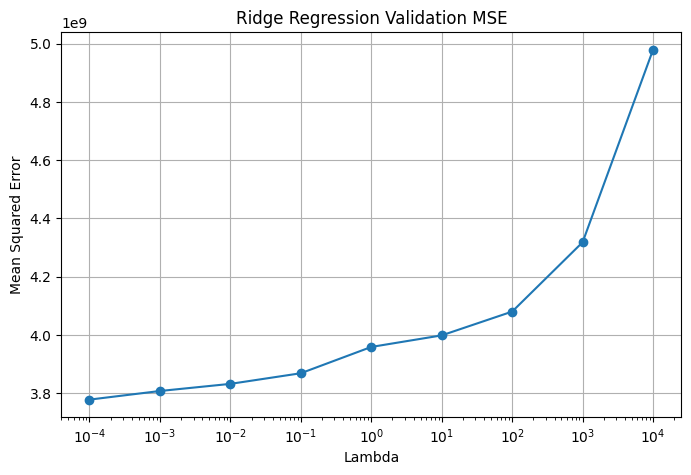

Best lambda:  0.0001
Ridge Regression Normal Test MSE: 3334247754.29, Validation MSE: 3778274473.13, Training MSE: 3522757973.35
Ridge Regression Normal Test MAE: 41181.34, Validation MAE: 42383.41, Training MAE: 41745.37


In [8]:
#w=(X^T * X + lambda*I)^-1 * X^T * y
#I is identity matrix

def ridge_regression_normal(X, y, lambda_):
    #np.eye creates an identity matrix of size (n_features, n_features)
    #1 in diagonal, 0 elsewhere
    #x.shape[1] -> number of features (columns)
    I = np.eye(X.shape[1])
    #do not regularize the bias term (intercept)
    I[0, 0] = 0
    #.solve more stable than .inv, solveses the linear system but avoids explicitly computing the inverse
    w_ridge = np.linalg.solve(X.T @ X + lambda_ * I, X.T @ y)
    return w_ridge

# lambda values
#wider range of lambda values to test for better regularization, smaller range had a constant MSE
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]

#ridge mean squared error for different lambda values
ridge_regression_mse=[]
#ridge_regression_mae=[]

for l in lambdas:
    w_ridge = ridge_regression_normal(X_train_b_r, y_train, l)
    y_val_pred_ridge = X_val_b_r @ w_ridge
    mse_val_ridge = mean_squared_error(y_val, y_val_pred_ridge)
    ridge_regression_mse.append(mse_val_ridge)
    #mae_validation_ridge=mean_absolute_error(y_val, y_val_pred_ridge)
    #ridge_regression_mae.append(mae_validation_ridge)

#fig,ax=plt.subplots(1,2,figsize=(12,5))
plt.figure(figsize=(8,5))
plt.plot(lambdas, ridge_regression_mse, marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression Validation MSE')
plt.grid()
plt.show()

# ax[1].plot(lambdas,ridge_regression_mae, marker='o')
# ax[1].set_xscale('log')
# ax[1].set_xlabel('Lambda')
# ax[1].set_ylabel('Mean Absolute Error')
# ax[1].set_title('Ridge Regression Validation MAE')
# ax[1].grid()

#finding the best lambda
#np.argmin returns the index of the minimum value in the array
best_lambda = lambdas[np.argmin(ridge_regression_mse)]
w_ridge_best = ridge_regression_normal(X_train_b_r, y_train, best_lambda)
y_test_pred_ridge_normal = X_test_b_r @ w_ridge_best
y_val_pred_ridge_normal = X_val_b_r @ w_ridge_best
y_train_pred_ridge_normal = X_train_b_r @ w_ridge_best
print("Best lambda: ", best_lambda)

mse_train_ridge_normal = mean_squared_error(y_train, y_train_pred_ridge_normal)
mse_val_ridge_normal = mean_squared_error(y_val, y_val_pred_ridge_normal)
mse_test_ridge_normal = mean_squared_error(y_test, y_test_pred_ridge_normal)
mae_train_ridge_normal = mean_absolute_error(y_train, y_train_pred_ridge_normal)
mae_val_ridge_normal = mean_absolute_error(y_val, y_val_pred_ridge_normal)
mae_test_ridge_normal = mean_absolute_error(y_test, y_test_pred_ridge_normal)

print(f"Ridge Regression Normal Test MSE: {mse_test_ridge_normal:.2f}, Validation MSE: {mse_val_ridge_normal:.2f}, Training MSE: {mse_train_ridge_normal:.2f}")
print(f"Ridge Regression Normal Test MAE: {mae_test_ridge_normal:.2f}, Validation MAE: {mae_val_ridge_normal:.2f}, Training MAE: {mae_train_ridge_normal:.2f}")


Ridge using gradient descent 

λ=0.0001, lr=0.001, iter=0, cost=56214485399.1749
λ=0.0001, lr=0.001, iter=500, cost=10598654206.9746
λ=0.0001, lr=0.001, iter=1000, cost=5364019461.7152
λ=0.0001, lr=0.001, iter=1500, cost=4562017194.5268
λ=0.0001, lr=0.001, iter=2000, cost=4386574430.1803
λ=0.0001, lr=0.001, iter=2500, cost=4313006556.3995
λ=0.0001, lr=0.0001, iter=0, cost=56214485367.2037
λ=0.0001, lr=0.0001, iter=500, cost=41825598699.1054
λ=0.0001, lr=0.0001, iter=1000, cost=34343614606.4181
λ=0.0001, lr=0.0001, iter=1500, cost=28801364205.5371
λ=0.0001, lr=0.0001, iter=2000, cost=24388600114.0128
λ=0.0001, lr=0.0001, iter=2500, cost=20809328409.8819
λ=0.001, lr=0.001, iter=0, cost=56214485689.8220
λ=0.001, lr=0.001, iter=500, cost=10599783819.7963
λ=0.001, lr=0.001, iter=1000, cost=5365576198.3430
λ=0.001, lr=0.001, iter=1500, cost=4563982294.7386
λ=0.001, lr=0.001, iter=2000, cost=4388927885.0255
λ=0.001, lr=0.001, iter=2500, cost=4315730819.1017
λ=0.001, lr=0.0001, iter=0, cost=56214485370.1102
λ=0.001, lr=0.00

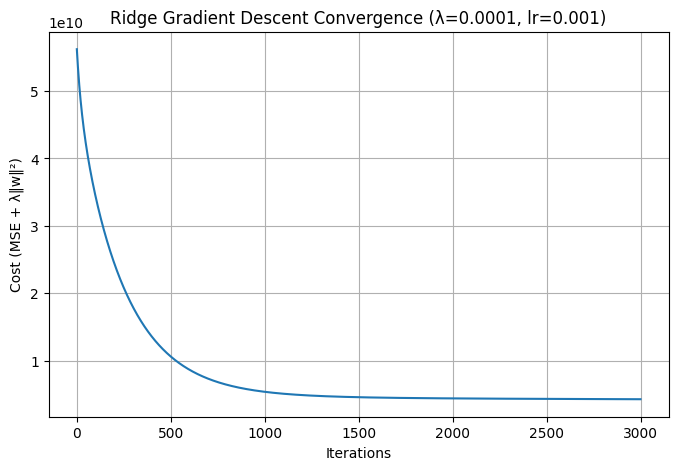

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_r = poly.fit_transform(X_train)
X_val_poly_r = poly.transform(X_val)
X_test_poly_r = poly.transform(X_test)

#feature scaling (standardization) to have mean=0 and std=1 for better convergence
scaler = StandardScaler()
X_train_scaled_r = scaler.fit_transform(X_train_poly_r)
X_val_scaled_r = scaler.transform(X_val_poly_r)
X_test_scaled_r = scaler.transform(X_test_poly_r)

#adding a ones column to the features for the bias (intercept)
#creates an array of ones with the same number of rows as X_train
#.c_ concatenates the ones column to X_train to the left side
X_train_b_r = np.c_[np.ones((X_train_scaled_r.shape[0], 1)), X_train_scaled_r]
X_val_b_r = np.c_[np.ones((X_val_scaled_r.shape[0], 1)), X_val_scaled_r]
X_test_b_r = np.c_[np.ones((X_test_scaled_r.shape[0], 1)), X_test_scaled_r]


# --- Gradient Descent for Ridge ---
def gradient_descent_ridge(X, y, lambda_, learning_rate=0.00001, n_iterations=10000):
    w = np.zeros(X.shape[1])
    n = X.shape[0]
    costs = []

    for iteration in range(n_iterations):
        y_pred = X @ w
        # gradients = (-2/n) * (X.T @ (y - y_pred)) + 2 * lambda_ * w
        # gradients[0] = (-2/n) * (X[:, 0].T @ (y - y_pred))  # no regularization for bias
        gradients = (-2/n) * (X.T @ (y - y_pred))
        gradients[1:] += (2 * lambda_ / n) * w[1:]
        w = w - learning_rate * gradients

        cost = (1/n) * np.sum((y - y_pred)**2) + lambda_ * np.sum(w[1:]**2)
        costs.append(cost)

        
        if iteration % 500 == 0:
            print(f"λ={lambda_}, lr={learning_rate}, iter={iteration}, cost={cost:.4f}")
        if iteration > 1 and abs(costs[-1] - costs[-2]) < 1e-6:
            print(f"Early stopping at iteration {iteration}, cost change < 1e-6")
            break
        if np.isnan(cost) or np.isinf(cost):
            print(f"Cost exploded at iteration {iteration}, stopping early.")
            break

    return w, costs


# --- Hyperparameter tuning ---
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]
# using lower learning rates to make weight update by little steps
learning_rates = [0.001, 0.0001]

#make sure the data is float64 to avoid overflow 
X_train_b_r = X_train_b_r.astype(np.float64)
X_val_b_r = X_val_b_r.astype(np.float64)
X_test_b_r = X_test_b_r.astype(np.float64)
y_train = y_train.astype(np.float64)
y_val = y_val.astype(np.float64)
y_test = y_test.astype(np.float64)

best_mse = float('inf')
best_lambda = None
best_lr = None


for l in lambdas:
    for lr in learning_rates:
        w_ridge_gd, _ = gradient_descent_ridge(X_train_b_r, y_train, lambda_=l, 
                                               learning_rate=lr, n_iterations=3000)        
        y_val_pred = X_val_b_r @ w_ridge_gd
        mse_val = mean_squared_error(y_val, y_val_pred)
        if mse_val < best_mse:
            best_mse = mse_val
            best_lambda = l
            best_lr = lr

print(f"\n Best Lambda: {best_lambda}, Best Learning Rate: {best_lr}, Best Validation MSE: {best_mse:.4f}")

# --- Final model ---
w_best, costs_best = gradient_descent_ridge(X_train_b_r, y_train, lambda_=best_lambda, learning_rate=best_lr, n_iterations=3000)

y_train_pred_gd = X_train_b_r @ w_best
y_val_pred_gd = X_val_b_r @ w_best
y_test_pred_gd = X_test_b_r @ w_best

mse_train_best = mean_squared_error(y_train, y_train_pred_gd)
mse_val_best = mean_squared_error(y_val, y_val_pred_gd)
mse_test_best = mean_squared_error(y_test, y_test_pred_gd)
mae_train_best = mean_absolute_error(y_train, y_train_pred_gd)
mae_val_best = mean_absolute_error(y_val, y_val_pred_gd)
mae_test_best = mean_absolute_error(y_test, y_test_pred_gd)

print(f"Train MSE: {mse_train_best:.2f}, Val MSE: {mse_val_best:.2f}, Test MSE: {mse_test_best:.2f}")
print(f"Train MAE: {mae_train_best:.2f}, Val MAE: {mae_val_best:.2f}, Test MAE: {mae_test_best:.2f}")

plt.figure(figsize=(8,5))
plt.plot(costs_best)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE + λ‖w‖²)")
plt.title(f"Ridge Gradient Descent Convergence (λ={best_lambda}, lr={best_lr})")
plt.grid(True)
plt.show()

# # --- Plot tuning curves ---
# plt.figure(figsize=(8,6))
# for lr in learning_rates:
#     mses = []
#     for l in lambdas:
#         w_tmp, _ = gradient_descent_ridge(X_train_b_r, y_train, lambda_=l, learning_rate=lr, n_iterations=1000)
#         y_val_pred = X_val_b_r @ w_tmp
#         mse_tmp = mean_squared_error(y_val, y_val_pred)
#         mses.append(mse_tmp)
#     plt.plot(lambdas, mses, marker='o', label=f'lr={lr}')

# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Lambda')
# plt.ylabel('Validation MSE')
# plt.title('Ridge Regression (Gradient Descent) Hyperparameter Tuning')
# plt.legend()
# plt.grid()
# plt.show()

ridge regression using sicklit 

Train MSE: 5028951106.6318, Validation MSE: 5191488928.1146, Test MSE: 4743371087.2324
Train MAE: 52876.3261, Validation MAE: 53495.4907, Test MAE: 51897.9847


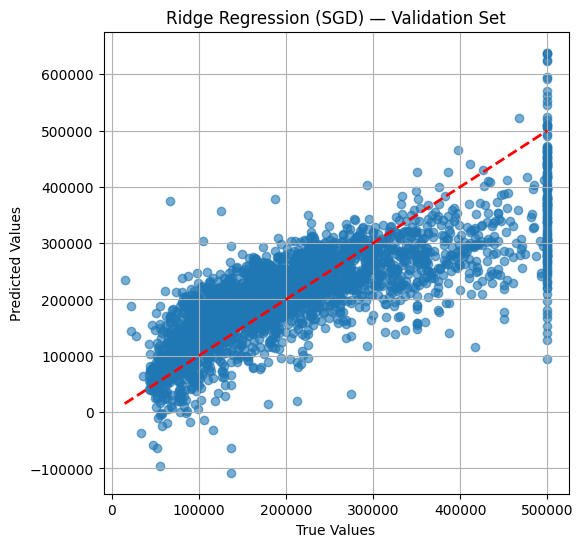


Ridge Regression using sklearn (SGD) — Model Accuracy (R² Score)
Train R²: 0.6246
Validation R²: 0.6015
Test R²: 0.6413


In [10]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Ridge Regression via Gradient Descent (SGDRegressor) ---
ridge_sgd = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        penalty='l2',           # L2 = Ridge regularization
        alpha=0.1,              # Regularization strength
        learning_rate='invscaling',
        eta0=0.01,              # Initial learning rate
        max_iter=1000,
        tol=1e-6,
        random_state=42
    )
)

# --- 2. Fit model ---
ridge_sgd.fit(X_train, y_train)

# --- 3. Predict on all sets ---
y_train_pred = ridge_sgd.predict(X_train)
y_val_pred = ridge_sgd.predict(X_val)
y_test_pred = ridge_sgd.predict(X_test)

# --- 4. Evaluate performance ---
mse_train = mean_squared_error(y_train, y_train_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Train MSE: {mse_train:.4f}, Validation MSE: {mse_val:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train MAE: {mae_train:.4f}, Validation MAE: {mae_val:.4f}, Test MAE: {mae_test:.4f}")

# --- 5. Plot true vs predicted values (Validation set) ---
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression (SGD) — Validation Set")
plt.grid(True)
plt.show()

# --- 6. Calculate and print R² (Accuracy-like metric) ---
print("\nRidge Regression using sklearn (SGD) — Model Accuracy (R² Score)")
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"Train R²: {r2_train:.4f}")
print(f"Validation R²: {r2_val:.4f}")
print(f"Test R²: {r2_test:.4f}")


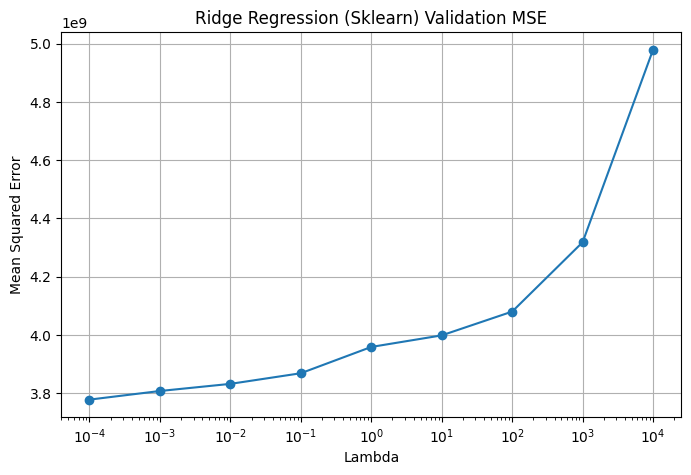

Best lambda (Sklearn):  0.0001
Ridge Regression (Sklearn) Test MSE: 3334247755.07, Validation MSE: 3778274473.45, Training MSE: 3522757973.80
Ridge Regression (Sklearn) Test MAE: 41181.34, Validation MAE: 42383.41, Training MAE: 41745.37


In [11]:
#ridge regression using sklearn for different lambda values
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]
ridge_sklearn_mse = []
#ridge_sklearn_mae = []

for l in lambdas:
    model = Ridge(alpha=l)
    model.fit(X_train_b_r, y_train)
    y_val_pred = model.predict(X_val_b_r)
    ridge_sklearn_mse.append(mean_squared_error(y_val, y_val_pred))
    #ridge_sklearn_mae.append(mean_absolute_error(y_val, y_val_pred))


plt.figure(figsize=(8,5))
plt.plot(lambdas, ridge_sklearn_mse, marker='o')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression (Sklearn) Validation MSE')
plt.grid()
plt.show()


#finding the best lambda
best_lambda_sklearn = lambdas[np.argmin(ridge_sklearn_mse)]
#finding the best model and training it on the whole training set
ridge_model = Ridge(alpha=best_lambda_sklearn)
ridge_model.fit(X_train_b_r, y_train)

#predictions
y_test_pred_ridge_sklearn = ridge_model.predict(X_test_b_r)
y_val_pred_ridge_sklearn = ridge_model.predict(X_val_b_r)
y_train_pred_ridge_sklearn = ridge_model.predict(X_train_b_r)
mse_ridge_train_sklearn = mean_squared_error(y_train, y_train_pred_ridge_sklearn)
mse_ridge_val_sklearn = mean_squared_error(y_val, y_val_pred_ridge_sklearn)
mse_ridge_test_sklearn = mean_squared_error(y_test, y_test_pred_ridge_sklearn)
mae_ridge_train_sklearn = mean_absolute_error(y_train, y_train_pred_ridge_sklearn)
mae_ridge_val_sklearn = mean_absolute_error(y_val, y_val_pred_ridge_sklearn)
mae_ridge_test_sklearn = mean_absolute_error(y_test, y_test_pred_ridge_sklearn)
print("Best lambda (Sklearn): ", best_lambda_sklearn)
print(f"Ridge Regression (Sklearn) Test MSE: {mse_ridge_test_sklearn:.2f}, Validation MSE: {mse_ridge_val_sklearn:.2f}, Training MSE: {mse_ridge_train_sklearn:.2f}")
print(f"Ridge Regression (Sklearn) Test MAE: {mae_ridge_test_sklearn:.2f}, Validation MAE: {mae_ridge_val_sklearn:.2f}, Training MAE: {mae_ridge_train_sklearn:.2f}")


In [ ]:
from sklearn.linear_model import Lasso
#split the data to 70% training, 30%
X_train, X_t, y_train, y_t = train_test_split(x, y, test_size=0.3, random_state=42)
#then to 15% val, 15% testing,random_state= any number, to use the same random testing every time
X_val, X_test, y_val, y_test = train_test_split(X_t, y_t, test_size=0.5, random_state=42)

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

#feature scaling (standardization) to have mean=0 and std=1 for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)
X_test_scaled = scaler.transform(X_test_poly)

#adding a ones column to the features for the bias (intercept)
#creates an array of ones with the same number of rows as X_train
#.c_ concatenates the ones column to X_train to the left side
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Lasso regression using sklearn for different lambda values
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]
lasso_sklearn_mse = []

for l in lambdas:
    model = Lasso(alpha=l, max_iter=5000, tol=1e-4)
    model.fit(X_train_b, y_train)
    y_val_pred = model.predict(X_val_b)
    mse_val = mean_squared_error(y_val, y_val_pred)
    lasso_sklearn_mse.append(mse_val)

# --- Plot validation MSE ---
plt.figure(figsize=(8,5))
plt.plot(lambdas, lasso_sklearn_mse, marker='o', color='orange')
plt.xscale('log')
plt.xlabel('Lambda (α)')
plt.ylabel('Validation MSE')
plt.title('Lasso Regression (Sklearn) Validation MSE')
plt.grid()
plt.show()

# --- Best lambda ---
best_lambda_sklearn = lambdas[np.argmin(lasso_sklearn_mse)]
print("Best lambda (Sklearn): ", best_lambda_sklearn)

# --- Train final model ---
lasso_model = Lasso(alpha=best_lambda_sklearn, max_iter=50000, tol=1e-4)
lasso_model.fit(X_train_b, y_train)

# --- Predictions ---
y_train_pred = lasso_model.predict(X_train_b)
y_val_pred = lasso_model.predict(X_val_b)
y_test_pred = lasso_model.predict(X_test_b)

# --- Metrics ---
mse_train = mean_squared_error(y_train, y_train_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Train MSE: {mse_train:.2f}, Val MSE: {mse_val:.2f}, Test MSE: {mse_test:.2f}")
print(f"Train MAE: {mae_train:.2f}, Val MAE: {mae_val:.2f}, Test MAE: {mae_test:.2f}")

C:\MachineLearning\Assignment1\California_Houses\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.725e+13, tolerance: 1.936e+10
  model = cd_fast.enet_coordinate_descent(
C:\MachineLearning\Assignment1\California_Houses\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.724e+13, tolerance: 1.936e+10
  model = cd_fast.enet_coordinate_descent(
C:\MachineLearning\Assignment1\California_Houses\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

In [ ]:
print("linear regression using normal equation model accuracy (R² Score) ")
r2_train = r2_score(y_train, y_train_pred_linear_normal)
r2_val = r2_score(y_val, y_val_pred_linear_normal)
r2_test = r2_score(y_test, y_test_pred_linear_normal)
print(f"Train R²: {r2_train:.4f}")
print(f"Validation R²: {r2_val:.4f}")
print(f"Test R²: {r2_test:.4f}")

print("\nlinear regression using gradient descent model accuracy (R² Score) ")
r2_train_gd = r2_score(y_train, y_train_pred_linear_gd)
r2_val_gd = r2_score(y_val, y_val_pred_linear_gd)
r2_test_gd = r2_score(y_test, y_test_pred_linear_gd)
print(f"Train R²: {r2_train_gd:.4f}")
print(f"Validation R²: {r2_val_gd:.4f}")
print(f"Test R²: {r2_test_gd:.4f}")

print("\n linear regression using sklearn model accuracy (R² Score) ")
r2_train_sklearn = r2_score(y_train, y_train_pred_linear_sklearn)
r2_val_sklearn = r2_score(y_val, y_val_pred_linear_sklearn)
r2_test_sklearn = r2_score(y_test, y_test_pred_linear_sklearn)
print(f"Train R²: {r2_train_sklearn:.4f}")
print(f"Validation R²: {r2_val_sklearn:.4f}")
print(f"Test R²: {r2_test_sklearn:.4f}")

print("\nRidge regression using normal equation model accuracy (R² Score) ")
r2_train_ridge_normal = r2_score(y_train, y_train_pred_ridge_normal)
r2_val_ridge_normal = r2_score(y_val, y_val_pred_ridge_normal)
r2_test_ridge_normal = r2_score(y_test, y_test_pred_ridge_normal)
print(f"Train R²: {r2_train_ridge_normal:.4f}")
print(f"Validation R²: {r2_val_ridge_normal:.4f}")
print(f"Test R²: {r2_test_ridge_normal:.4f}")

print("\nRidge regression using gradient descent model accuracy (R² Score) ")
r2_train_ridge_gd = r2_score(y_train, y_train_pred_gd)
r2_val_ridge_gd = r2_score(y_val, y_val_pred_gd)
r2_test_ridge_gd = r2_score(y_test, y_test_pred_gd)
print(f"Train R²: {r2_train_ridge_gd:.4f}")
print(f"Validation R²: {r2_val_ridge_gd:.4f}")
print(f"Test R²: {r2_test_ridge_gd:.4f}")

print("\nRidge regression using sklearn model accuracy (R² Score) ")
r2_train_ridge_sklearn = r2_score(y_train, y_train_pred_ridge_sklearn)
r2_val_ridge_sklearn = r2_score(y_val, y_val_pred_ridge_sklearn)
r2_test_ridge_sklearn = r2_score(y_test, y_test_pred_ridge_sklearn)
print(f"Train R²: {r2_train_ridge_sklearn:.4f}")
print(f"Validation R²: {r2_val_ridge_sklearn:.4f}")
print(f"Test R²: {r2_test_ridge_sklearn:.4f}")

print("\nLasso regression using sklearn model accuracy (R² Score) ")
r2_train_lasso_sklearn = r2_score(y_train, y_train_pred_lasso_sklearn)
r2_val_lasso_sklearn = r2_score(y_val, y_val_pred_lasso_sklearn)
r2_test_lasso_sklearn = r2_score(y_test, y_test_pred_lasso_sklearn)
print(f"Train R²: {r2_train_lasso_sklearn:.4f}")
print(f"Validation R²: {r2_val_lasso_sklearn:.4f}")
print(f"Test R²: {r2_test_lasso_sklearn:.4f}")

In [ ]:
# alphas (lambdas)
# We'll use a wide range, similar to your manual ridge, adding 100
alphas_lasso = [0, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100]
lasso_sklearn_mse = []

print("Starting Lasso alpha tuning...")

for a in alphas_lasso:
    # Note: alpha=0 is equivalent to Linear Regression
    # We set max_iter high to ensure convergence
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_train_b_r, y_train)
    y_val_pred = model.predict(X_val_b_r)
    lasso_sklearn_mse.append(mean_squared_error(y_val, y_val_pred))

print("Lasso alpha tuning complete.")
print(f"Alphas tested: {alphas_lasso}")
print(f"Validation MSEs: {lasso_sklearn_mse}")

plt.figure(figsize=(8,5))
plt.plot(alphas_lasso, lasso_sklearn_mse, marker='o')
plt.xscale('log') # This will show a warning due to the '0' value, but it will still plot correctly
plt.xlabel('Alpha (Lambda)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Regression (Sklearn) Validation MSE')
plt.grid(True)
plt.savefig('lasso_sklearn_mse_plot.png')
print("Lasso MSE plot saved as lasso_sklearn_mse_plot.png")
# Find the best alpha from our list
best_alpha_lasso = alphas_lasso[np.argmin(lasso_sklearn_mse)]

# Train the best model
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(X_train_b_r, y_train)

# Predictions
y_test_pred_lasso_sklearn = lasso_model.predict(X_test_b_r)
y_val_pred_lasso_sklearn = lasso_model.predict(X_val_b_r)
y_train_pred_lasso_sklearn = lasso_model.predict(X_train_b_r)

# MSE
mse_lasso_train_sklearn = mean_squared_error(y_train, y_train_pred_lasso_sklearn)
mse_lasso_val_sklearn = mean_squared_error(y_val, y_val_pred_lasso_sklearn)
mse_lasso_test_sklearn = mean_squared_error(y_test, y_test_pred_lasso_sklearn)

# MAE
mae_lasso_train_sklearn = mean_absolute_error(y_train, y_train_pred_lasso_sklearn)
mae_lasso_val_sklearn = mean_absolute_error(y_val, y_val_pred_lasso_sklearn)
mae_lasso_test_sklearn = mean_absolute_error(y_test, y_test_pred_lasso_sklearn)

print(f"Best alpha (Sklearn) for Lasso: {best_alpha_lasso}")
print(f"Lasso Regression (Sklearn) Test MSE: {mse_lasso_test_sklearn:.2f}, Validation MSE: {mse_lasso_val_sklearn:.2f}, Training MSE: {mse_lasso_train_sklearn:.2f}")
print(f"Lasso Regression (Sklearn) Test MAE: {mae_lasso_test_sklearn:.2f}, Validation MAE: {mae_lasso_val_sklearn:.2f}, Training MAE: {mae_lasso_train_sklearn:.2f}")